# Download and Inspect PanCollection — WorldView-3

## لماذا WorldView-3؟

الداتا الخاصة بالمشروع:

```text
PAN: 0.3 m/pixel
MS:  1.2 m/pixel
Scale factor: ×4
MS bands: 6
```

WorldView-3 قريب جدًا مكانيًا:

```text
PAN: حوالي 0.31 m/pixel
MS:  حوالي 1.24 m/pixel
Scale factor: ×4
MS bands: 8
```

سننزّل **WV3 فقط** من PanCollection ثم نفحص:

- أسماء ملفات H5.
- المفاتيح داخل كل ملف.
- Shapes.
- عدد الـBands.
- ترتيب الأبعاد.
- Range القيم.
- عينة مرئية.

> لا نبدأ Pretraining قبل معرفة شكل الداتا الفعلي. داتاك 6 Bands وWV3 فيه 8 Bands، لذلك يجب لاحقًا اختيار استراتيجية Transfer صحيحة بدل دمج القنوات عشوائيًا.


## 1) تثبيت المكتبات وربط Google Drive

In [1]:
!pip install -q -U huggingface_hub hf_xet h5py numpy matplotlib pandas

from google.colab import drive
drive.mount("/content/drive")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 51.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompati

## 2) المسارات والإعدادات

الداتا ستُحفظ داخل:

```text
MyDrive/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3/
```


In [3]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Super_Resolution_28-07-2026"
)

WV3_DIR = (
    PROJECT_DIR
    / "Public_Datasets"
    / "PanCollection_WV3"
)

WV3_DIR.mkdir(parents=True, exist_ok=True)

REPO_ID = "elsting/PanCollection"

print("Dataset destination:", WV3_DIR)
print("Repository:", REPO_ID)


Dataset destination: /content/drive/MyDrive/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3
Repository: elsting/PanCollection


## 3) عرض ملفات WorldView-3 الموجودة في المستودع

هذه الخلية لا تنزّل الملفات بعد.


In [4]:
from huggingface_hub import HfApi

api = HfApi()

repo_files = api.list_repo_files(
    repo_id=REPO_ID,
    repo_type="dataset",
)

wv3_files = [
    file_name
    for file_name in repo_files
    if "wv3" in file_name.lower()
]

print("Total repository files:", len(repo_files))
print("WV3-related files:", len(wv3_files))

for index, file_name in enumerate(wv3_files, start=1):
    print(f"{index:02d}. {file_name}")

if not wv3_files:
    raise RuntimeError(
        "لم يتم العثور على ملفات تحمل WV3 في اسمها."
    )


Total repository files: 18
WV3-related files: 5
01. test_data/test_wv3_OrigScale_multiExm1.h5
02. test_data/test_wv3_multiExm1.h5
03. test_data/wv3_reduce.png
04. training_data/train_wv3_9714.h5
05. training_data/valid_wv3_9714.h5


## 4) تنزيل ملفات WV3 فقط

قد يكون حجم Training Dataset عدة جيجابايت. لا تغلق Colab أثناء التنزيل.

لو كنت تريد فحص ملفات Test الصغيرة أولًا، غيّر:

```python
DOWNLOAD_TRAINING = False
```

بعد نجاح الفحص، أعدها إلى `True` لتنزيل Training Dataset.


In [5]:
from huggingface_hub import snapshot_download

DOWNLOAD_TRAINING = False

selected_files = []

for file_name in wv3_files:
    lower_name = file_name.lower()

    if DOWNLOAD_TRAINING:
        selected_files.append(file_name)
    else:
        # Download likely test/validation files only for initial inspection
        if (
            "test" in lower_name
            or "valid" in lower_name
            or "validation" in lower_name
        ):
            selected_files.append(file_name)

if not selected_files:
    print(
        "لم أجد أسماء Test واضحة؛ سيتم اختيار أول ملفين WV3 للفحص."
    )
    selected_files = wv3_files[:2]

print("Files selected for download:")

for file_name in selected_files:
    print(" -", file_name)

snapshot_path = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    allow_patterns=selected_files,
    local_dir=str(WV3_DIR),
)

print("Download completed.")
print("Local snapshot:", snapshot_path)


Files selected for download:
 - test_data/test_wv3_OrigScale_multiExm1.h5
 - test_data/test_wv3_multiExm1.h5
 - test_data/wv3_reduce.png
 - training_data/valid_wv3_9714.h5


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Download completed.
Local snapshot: /content/drive/.shortcut-targets-by-id/18x9ASVG9rA2MORESGQwDT7a8n-OLOdQu/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3


## 5) عرض الملفات التي تم تنزيلها وحجمها

In [6]:
downloaded_files = sorted(
    path
    for path in WV3_DIR.rglob("*")
    if path.is_file()
)

print("Downloaded files:", len(downloaded_files))

for path in downloaded_files:
    size_mb = path.stat().st_size / 1024**2

    print(
        f"{size_mb:10.2f} MB | "
        f"{path.relative_to(WV3_DIR)}"
    )


Downloaded files: 15
      0.00 MB | .cache/huggingface/.gitignore
      0.00 MB | .cache/huggingface/CACHEDIR.TAG
      0.00 MB | .cache/huggingface/download/test_data/test_wv3_OrigScale_multiExm1.h5.lock
      0.00 MB | .cache/huggingface/download/test_data/test_wv3_OrigScale_multiExm1.h5.metadata
      0.00 MB | .cache/huggingface/download/test_data/test_wv3_multiExm1.h5.lock
      0.00 MB | .cache/huggingface/download/test_data/test_wv3_multiExm1.h5.metadata
      0.00 MB | .cache/huggingface/download/test_data/wv3_reduce.png.lock
      0.00 MB | .cache/huggingface/download/test_data/wv3_reduce.png.metadata
      0.00 MB | .cache/huggingface/download/training_data/valid_wv3_9714.h5.lock
      0.00 MB | .cache/huggingface/download/training_data/valid_wv3_9714.h5.metadata
      0.01 MB | .cache/huggingface/trees/b39e5daf0a322105977a7d4ce53ca0c4806defed.json
    380.00 MB | test_data/test_wv3_OrigScale_multiExm1.h5
    175.00 MB | test_data/test_wv3_multiExm1.h5
      2.77 MB | test_d

## 6) فحص بنية ملفات H5 بدون تحميلها بالكامل

In [7]:
import h5py
import pandas as pd

h5_files = [
    path
    for path in downloaded_files
    if path.suffix.lower() in {".h5", ".hdf5", ".mat"}
]

if not h5_files:
    raise RuntimeError(
        "لم يتم العثور على H5/MAT v7.3 files."
    )


def inspect_h5_file(file_path):
    rows = []

    with h5py.File(file_path, "r") as h5_file:

        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                rows.append({
                    "file": str(file_path.relative_to(WV3_DIR)),
                    "key": name,
                    "shape": str(obj.shape),
                    "dtype": str(obj.dtype),
                    "ndim": obj.ndim,
                })

        h5_file.visititems(visitor)

    return rows


inspection_rows = []

for file_path in h5_files:
    inspection_rows.extend(
        inspect_h5_file(file_path)
    )

inspection_df = pd.DataFrame(inspection_rows)

display(inspection_df)

INSPECTION_CSV = WV3_DIR / "wv3_h5_structure.csv"
inspection_df.to_csv(
    INSPECTION_CSV,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", INSPECTION_CSV)


,file,key,shape,dtype,ndim
0,test_data/test_wv3_OrigScale_multiExm1.h5,lms,"(20, 8, 512, 512)",float64,4
1,test_data/test_wv3_OrigScale_multiExm1.h5,ms,"(20, 8, 128, 128)",float64,4
2,test_data/test_wv3_OrigScale_multiExm1.h5,pan,"(20, 1, 512, 512)",float64,4
3,test_data/test_wv3_multiExm1.h5,gt,"(20, 8, 256, 256)",float64,4
4,test_data/test_wv3_multiExm1.h5,lms,"(20, 8, 256, 256)",float64,4
5,test_data/test_wv3_multiExm1.h5,ms,"(20, 8, 64, 64)",float64,4
6,test_data/test_wv3_multiExm1.h5,pan,"(20, 1, 256, 256)",float64,4
7,training_data/valid_wv3_9714.h5,gt,"(1080, 8, 64, 64)",float64,4
8,training_data/valid_wv3_9714.h5,lms,"(1080, 8, 64, 64)",float64,4
9,training_data/valid_wv3_9714.h5,ms,"(1080, 8, 16, 16)",float64,4


Saved: /content/drive/MyDrive/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3/wv3_h5_structure.csv


## 7) تحديد ملف للفحص المرئي

يتم اختيار أول ملف H5 تلقائيًا. يمكن تغييره لاحقًا.


In [8]:
SAMPLE_FILE = h5_files[0]

print("Selected file:")
print(SAMPLE_FILE)


Selected file:
/content/drive/MyDrive/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3/test_data/test_wv3_OrigScale_multiExm1.h5


## 8) قراءة المفاتيح واكتشاف MS/PAN/GT بصورة مبدئية

الأسماء الشائعة في Pansharpening Datasets تشمل:

```text
ms, lms, pan, gt
```

لكن الكود لا يفترضها مسبقًا؛ سيطبع كل المفاتيح أولًا.


In [9]:
with h5py.File(SAMPLE_FILE, "r") as h5_file:
    dataset_keys = []

    def collect_keys(name, obj):
        if isinstance(obj, h5py.Dataset):
            dataset_keys.append(name)

    h5_file.visititems(collect_keys)

print("Dataset keys:")

for key in dataset_keys:
    print(" -", key)


def find_key(candidates, available_keys):
    lower_map = {
        key.lower(): key
        for key in available_keys
    }

    # Exact match first
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    # Contains match second
    for candidate in candidates:
        for key in available_keys:
            if candidate.lower() in key.lower():
                return key

    return None


PAN_KEY = find_key(
    ["pan", "panchromatic"],
    dataset_keys,
)

LR_MS_KEY = find_key(
    ["ms", "lrms", "ms_lr"],
    dataset_keys,
)

UPSAMPLED_MS_KEY = find_key(
    ["lms", "up_ms", "upsampled_ms"],
    dataset_keys,
)

GT_KEY = find_key(
    ["gt", "target", "hrms", "ms_label"],
    dataset_keys,
)

print("\nDetected keys:")
print("PAN       :", PAN_KEY)
print("LR-MS     :", LR_MS_KEY)
print("Upsampled :", UPSAMPLED_MS_KEY)
print("GT        :", GT_KEY)


Dataset keys:
 - lms
 - ms
 - pan

Detected keys:
PAN       : pan
LR-MS     : ms
Upsampled : lms
GT        : None


## 9) دوال استخراج Sample والتعرف على ترتيب القنوات

تدعم بصورة مبدئية:

```text
NCHW
NHWC
CHWN
HWCN
```

سنطبع الشكل قبل وبعد التحويل بدل الاعتماد على تخمين صامت.


In [10]:
import numpy as np


def read_first_sample(dataset):
    shape = dataset.shape

    if dataset.ndim == 4:
        # Usually the sample dimension is the largest dimension.
        candidate_sample_axes = [
            axis
            for axis, size in enumerate(shape)
            if size > 16
        ]

        # Prefer axis 0, then last axis.
        if shape[0] > 16:
            array = dataset[0]
            sample_axis = 0
        elif shape[-1] > 16:
            array = dataset[..., 0]
            sample_axis = dataset.ndim - 1
        else:
            array = dataset[0]
            sample_axis = 0

    elif dataset.ndim in {2, 3}:
        array = dataset[()]
        sample_axis = None

    else:
        raise ValueError(
            f"Unsupported dataset shape: {shape}"
        )

    return np.asarray(array), sample_axis


def to_chw(array):
    if array.ndim == 2:
        return array[None, :, :], "HW → CHW"

    if array.ndim != 3:
        raise ValueError(
            f"Expected 2D or 3D sample, got {array.shape}"
        )

    # Channel-first
    if array.shape[0] <= 16:
        return array, "Already CHW"

    # Channel-last
    if array.shape[-1] <= 16:
        return np.moveaxis(array, -1, 0), "HWC → CHW"

    raise ValueError(
        "لم أستطع تحديد محور القنوات تلقائيًا: "
        f"{array.shape}"
    )


def load_key_as_chw(file_path, key):
    if key is None:
        return None

    with h5py.File(file_path, "r") as h5_file:
        dataset = h5_file[key]
        raw_sample, sample_axis = read_first_sample(dataset)

    chw_sample, conversion = to_chw(raw_sample)

    print("\nKey:", key)
    print("Stored shape :", dataset.shape)
    print("Sample axis  :", sample_axis)
    print("Raw sample   :", raw_sample.shape)
    print("Converted CHW:", chw_sample.shape)
    print("Conversion   :", conversion)
    print("Dtype        :", chw_sample.dtype)
    print(
        "Range        :",
        float(np.nanmin(chw_sample)),
        "→",
        float(np.nanmax(chw_sample)),
    )

    return chw_sample


pan_sample = load_key_as_chw(
    SAMPLE_FILE,
    PAN_KEY,
)

lr_ms_sample = load_key_as_chw(
    SAMPLE_FILE,
    LR_MS_KEY,
)

lms_sample = load_key_as_chw(
    SAMPLE_FILE,
    UPSAMPLED_MS_KEY,
)

gt_sample = load_key_as_chw(
    SAMPLE_FILE,
    GT_KEY,
)



Key: pan
Stored shape : (20, 1, 512, 512)
Sample axis  : 0
Raw sample   : (1, 512, 512)
Converted CHW: (1, 512, 512)
Conversion   : Already CHW
Dtype        : float64
Range        : 1.0 → 2047.0

Key: ms
Stored shape : (20, 8, 128, 128)
Sample axis  : 0
Raw sample   : (8, 128, 128)
Converted CHW: (8, 128, 128)
Conversion   : Already CHW
Dtype        : float64
Range        : 1.0 → 2047.0

Key: lms
Stored shape : (20, 8, 512, 512)
Sample axis  : 0
Raw sample   : (8, 512, 512)
Converted CHW: (8, 512, 512)
Conversion   : Already CHW
Dtype        : float64
Range        : -208.8250922553457 → 2161.178376627436


## 10) عرض عينة مرئية

ترتيب Bands في WV3 ليس بالضرورة RGB 1-2-3. العرض هنا مبدئي لفحص التطابق المكاني فقط.


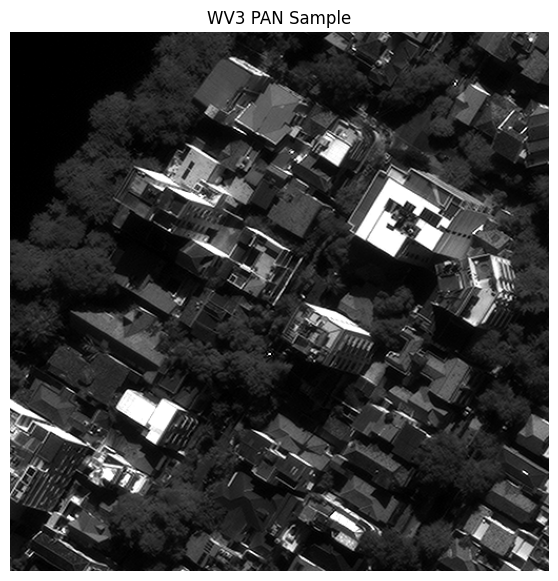

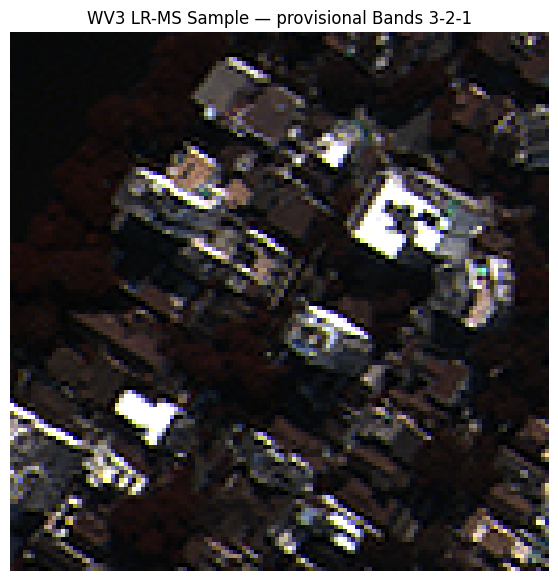

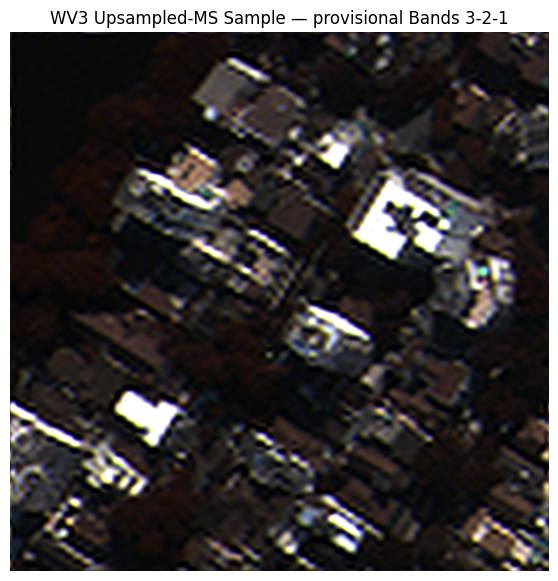

In [11]:
import matplotlib.pyplot as plt


def stretch_band(band):
    band = band.astype(np.float32)
    valid = band[np.isfinite(band)]

    if valid.size == 0:
        return np.zeros_like(
            band,
            dtype=np.float32,
        )

    low, high = np.percentile(
        valid,
        [2, 98],
    )

    if high <= low:
        high = low + 1.0

    return np.clip(
        (band - low) / (high - low),
        0,
        1,
    )


def preview_rgb(chw):
    if chw is None or chw.shape[0] < 3:
        return None

    return np.stack(
        [
            stretch_band(chw[2]),
            stretch_band(chw[1]),
            stretch_band(chw[0]),
        ],
        axis=-1,
    )


if pan_sample is not None:
    plt.figure(figsize=(7, 7))
    plt.imshow(
        stretch_band(pan_sample[0]),
        cmap="gray",
    )
    plt.title("WV3 PAN Sample")
    plt.axis("off")
    plt.show()


for title, sample in [
    ("WV3 LR-MS Sample", lr_ms_sample),
    ("WV3 Upsampled-MS Sample", lms_sample),
    ("WV3 Ground Truth MS", gt_sample),
]:
    rgb = preview_rgb(sample)

    if rgb is not None:
        plt.figure(figsize=(7, 7))
        plt.imshow(rgb)
        plt.title(
            f"{title} — provisional Bands 3-2-1"
        )
        plt.axis("off")
        plt.show()


## 11) التحقق من العلاقة ×4 في Sample

التحقق المتوقع في Reduced-Resolution Dataset:

```text
LR-MS height × 4 = GT height
LR-MS width  × 4 = GT width
PAN shape = GT spatial shape
```


In [12]:
print("Shapes:")

if lr_ms_sample is not None:
    print("LR-MS:", lr_ms_sample.shape)

if pan_sample is not None:
    print("PAN  :", pan_sample.shape)

if gt_sample is not None:
    print("GT   :", gt_sample.shape)


if (
    lr_ms_sample is not None
    and pan_sample is not None
    and gt_sample is not None
):
    spatial_scale_h = (
        gt_sample.shape[-2]
        / lr_ms_sample.shape[-2]
    )

    spatial_scale_w = (
        gt_sample.shape[-1]
        / lr_ms_sample.shape[-1]
    )

    print("\nScale H:", spatial_scale_h)
    print("Scale W:", spatial_scale_w)
    print(
        "PAN and GT same spatial size:",
        pan_sample.shape[-2:]
        == gt_sample.shape[-2:],
    )


Shapes:
LR-MS: (8, 128, 128)
PAN  : (1, 512, 512)


# ماذا ترسل بعد التشغيل؟

في التشغيل الأول اترك:

```python
DOWNLOAD_TRAINING = False
```

وأرسل:

1. قائمة ملفات WV3 التي وجدها المستودع.
2. جدول المفاتيح وShapes.
3. `Detected keys`.
4. شكل كل Sample بعد التحويل إلى CHW.
5. نتيجة Scale H وScale W.

بعد التأكد من شكل الملفات، نغيّر:

```python
DOWNLOAD_TRAINING = True
```

ثم نبني Notebook Pretraining مناسبة فعلًا لعدد Bands وترتيب البيانات.
